TITANIC ASSIGNMENT 2: DATA CLEANING, FEATURE ENGINEERING & SELECTION

📊 LOADING TITANIC DATASET...
Shape: (891, 12)
Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First 3 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  

PART 1: DATA CLEANING

Missing values before cleaning:
Age         177
Cabin

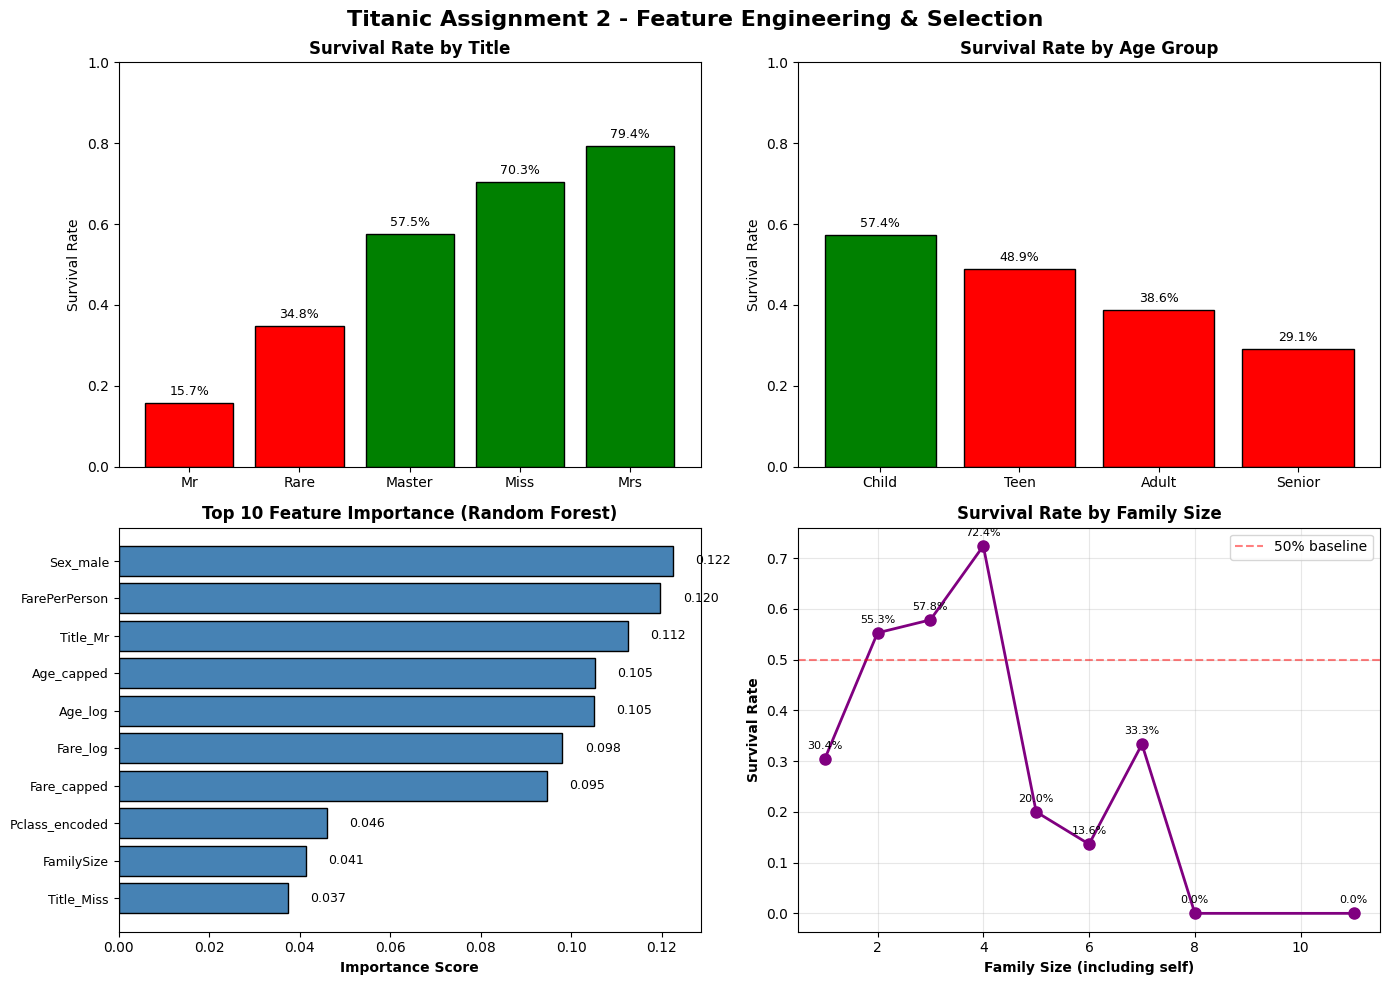


SAVING PROCESSED DATA
✅ Processed dataset saved to: data/train_processed.csv
✅ Cleaned dataset saved to: data/train_cleaned.csv

🏆 ASSIGNMENT 2 COMPLETE - FINAL SUMMARY 🏆

✅ PART 1: DATA CLEANING (10 MARKS)
   • Missing values handled
   • Outliers capped
   • Cleaned dataset saved

✅ PART 2: FEATURE ENGINEERING (30 MARKS)
   • FamilySize, IsAlone
   • Title extraction
   • AgeGroup (Child, Teen, Adult, Senior)
   • FarePerPerson
   • Log transformations
   • One-hot encoding
   • Ordinal encoding

✅ PART 3: FEATURE SELECTION (10 MARKS)
   • Correlation analysis
   • Random Forest importance
   • Selected 10 optimal features

✅ TOP FEATURES SELECTED:
   Sex_male, FarePerPerson, Title_Mr, Age_capped, Age_log...

📁 FILES GENERATED:
   • data/train_cleaned.csv
   • data/train_processed.csv

🎉 ASSIGNMENT 2 COMPLETED SUCCESSFULLY!


In [1]:
# ============================================
# ASSIGNMENT 2: TITANIC SURVIVAL ANALYSIS
# No Seaborn Required - Uses Matplotlib Only
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)

print("="*80)
print("TITANIC ASSIGNMENT 2: DATA CLEANING, FEATURE ENGINEERING & SELECTION")
print("="*80)

# ============================================
# LOAD DATA
# ============================================
print("\n📊 LOADING TITANIC DATASET...")

# Load the data
df = pd.read_csv('data/train.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 3 rows:")
print(df.head(3))

# ============================================
# PART 1: DATA CLEANING
# ============================================
print("\n" + "="*80)
print("PART 1: DATA CLEANING")
print("="*80)

# Check missing values
print("\nMissing values before cleaning:")
missing = df.isnull().sum()
print(missing[missing > 0])

# Make a copy for cleaning
df_clean = df.copy()

# 1. Handle Age missing values - fill with median
df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
print("\n Age: Filled with median ({:.1f})".format(df['Age'].median()))

# 2. Handle Embarked missing values - fill with mode 'S'
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)
print(" Embarked: Filled with mode ('S')")

# 3. Handle Cabin - create indicator column (77% missing)
df_clean['Cabin_Unknown'] = df_clean['Cabin'].isnull().astype(int)
df_clean.drop('Cabin', axis=1, inplace=True)
print(" Cabin: Created 'Cabin_Unknown' indicator, dropped original")

# 4. Handle outliers - Fare (cap at 95th percentile)
fare_95 = df_clean['Fare'].quantile(0.95)
df_clean['Fare_capped'] = np.where(df_clean['Fare'] > fare_95, fare_95, df_clean['Fare'])
print(f"Fare: Capped at 95th percentile ({fare_95:.2f})")

# 5. Handle outliers - Age (cap at 99th percentile)
age_99 = df_clean['Age'].quantile(0.99)
df_clean['Age_capped'] = np.where(df_clean['Age'] > age_99, age_99, df_clean['Age'])
print(f" Age: Capped at 99th percentile ({age_99:.2f})")

# 6. Remove duplicates if any
duplicates = df_clean.duplicated().sum()
if duplicates > 0:
    df_clean.drop_duplicates(inplace=True)
    print(f"Removed {duplicates} duplicate rows")
else:
    print(" No duplicate rows found")

print("\n Data cleaning complete!")

# ============================================
# PART 2: FEATURE ENGINEERING
# ============================================
print("\n" + "="*80)
print("PART 2: FEATURE ENGINEERING")
print("="*80)

df_fe = df_clean.copy()

# 2.1 Family Size Features
print("\n Creating Family Features...")
df_fe['FamilySize'] = df_fe['SibSp'] + df_fe['Parch'] + 1
df_fe['IsAlone'] = (df_fe['FamilySize'] == 1).astype(int)
print("   ✓ FamilySize = SibSp + Parch + 1")
print("   ✓ IsAlone = 1 if FamilySize == 1 else 0")

# 2.2 Title Extraction from Name
print("\n Extracting Titles from Names...")
df_fe['Title'] = df_fe['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
    'Mlle': 'Miss', 'Mme': 'Mrs', 'Ms': 'Miss', 'Lady': 'Rare',
    'Countess': 'Rare', 'Jonkheer': 'Rare', 'Don': 'Rare', 'Sir': 'Rare',
    'Capt': 'Rare'
}
df_fe['Title'] = df_fe['Title'].map(title_mapping).fillna('Rare')
print("   ✓ Extracted: Mr, Mrs, Miss, Master, Rare")

# 2.3 Age Groups
print("\n Creating Age Groups...")
def age_group(age):
    if age < 12:
        return 'Child'
    elif age < 18:
        return 'Teen'
    elif age < 60:
        return 'Adult'
    else:
        return 'Senior'
df_fe['AgeGroup'] = df_fe['Age'].apply(age_group)
print("   ✓ Groups: Child (0-11), Teen (12-17), Adult (18-59), Senior (60+)")

# 2.4 Fare per Person
print("\n Creating Fare per Person...")
df_fe['FarePerPerson'] = df_fe['Fare'] / df_fe['FamilySize']
print("   ✓ FarePerPerson = Fare / FamilySize")

# 2.5 Log Transformations
print("\n Applying Log Transformations...")
df_fe['Fare_log'] = np.log1p(df_fe['Fare_capped'])
df_fe['Age_log'] = np.log1p(df_fe['Age_capped'])
print("   ✓ Fare_log = log(1 + Fare_capped)")
print("   ✓ Age_log = log(1 + Age_capped)")

# Display new features
print("\n New Features Created:")
print(df_fe[['FamilySize', 'IsAlone', 'Title', 'AgeGroup', 'FarePerPerson']].head())

# ============================================
# CATEGORICAL ENCODING
# ============================================
print("\n" + "="*80)
print("CATEGORICAL ENCODING")
print("="*80)

# One-hot encode nominal features
print("\n One-hot Encoding...")
nominal_cols = ['Sex', 'Embarked', 'Title', 'AgeGroup']
df_encoded = pd.get_dummies(df_fe, columns=nominal_cols, drop_first=True)
print(f"   One-hot encoded: {nominal_cols}")
print(f"   New shape after encoding: {df_encoded.shape}")

# Ordinal encoding for Pclass
print("\n Ordinal Encoding for Pclass...")
pclass_mapping = {1: 3, 2: 2, 3: 1}
df_encoded['Pclass_encoded'] = df_encoded['Pclass'].map(pclass_mapping)
df_encoded.drop('Pclass', axis=1, inplace=True)
print("   Pclass: 1st→3, 2nd→2, 3rd→1")

# ============================================
# PART 3: FEATURE SELECTION
# ============================================
print("\n" + "="*80)
print("PART 3: FEATURE SELECTION")
print("="*80)

# Prepare features for modeling
exclude_cols = ['PassengerId', 'Survived', 'Name', 'Ticket', 'Fare', 'Age', 'SibSp', 'Parch']
feature_cols = [col for col in df_encoded.columns if col not in exclude_cols]

X = df_encoded[feature_cols]
y = df_encoded['Survived']

print(f"\nFeature matrix shape: {X.shape[0]} samples, {X.shape[1]} features")

# 3.1 Correlation Analysis
print("\n Correlation with Survival...")
correlations = X.corrwith(y).sort_values(ascending=False)
print("\nTop 10 features by correlation:")
for i, (feat, corr) in enumerate(correlations.head(10).items(), 1):
    print(f"   {i}. {feat:25} {corr:.4f}")

# 3.2 Random Forest Feature Importance
print("\n Random Forest Feature Importance...")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 features by Random Forest importance:")
for i, row in importance_df.head(10).iterrows():
    print(f"   {i+1}. {row['Feature']:25} {row['Importance']:.4f}")

# 3.3 Final Feature Selection
print("\n Final Recommended Features...")
final_features = list(importance_df.head(10)['Feature'].values)
print("\n FINAL 10 FEATURES FOR MODEL:")
for i, feat in enumerate(final_features, 1):
    corr_val = correlations[feat] if feat in correlations else 0
    print(f"   {i}. {feat:25} (correlation: {corr_val:.4f})")

# ============================================
# VISUALIZATIONS (Matplotlib Only)
# ============================================
print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Titanic Assignment 2 - Feature Engineering & Selection', fontsize=16, fontweight='bold')

# Plot 1: Survival by Title
title_survival = df_fe.groupby('Title')['Survived'].mean().sort_values()
colors1 = ['green' if x > 0.5 else 'red' for x in title_survival.values]
axes[0,0].bar(title_survival.index, title_survival.values, color=colors1, edgecolor='black')
axes[0,0].set_title('Survival Rate by Title', fontweight='bold')
axes[0,0].set_ylabel('Survival Rate')
axes[0,0].set_ylim(0, 1)
for i, (title, rate) in enumerate(title_survival.items()):
    axes[0,0].text(i, rate + 0.02, f'{rate:.1%}', ha='center', fontsize=9)

# Plot 2: Survival by Age Group
age_survival = df_fe.groupby('AgeGroup')['Survived'].mean().reindex(['Child', 'Teen', 'Adult', 'Senior'])
colors2 = ['green' if x > 0.5 else 'red' for x in age_survival.values]
axes[0,1].bar(age_survival.index, age_survival.values, color=colors2, edgecolor='black')
axes[0,1].set_title('Survival Rate by Age Group', fontweight='bold')
axes[0,1].set_ylabel('Survival Rate')
axes[0,1].set_ylim(0, 1)
for i, (group, rate) in enumerate(age_survival.items()):
    axes[0,1].text(i, rate + 0.02, f'{rate:.1%}', ha='center', fontsize=9)

# Plot 3: Feature Importance (Top 10)
top_10_features = importance_df.head(10)
axes[1,0].barh(range(len(top_10_features)), top_10_features['Importance'].values, 
               color='steelblue', edgecolor='black')
axes[1,0].set_yticks(range(len(top_10_features)))
axes[1,0].set_yticklabels(top_10_features['Feature'].values, fontsize=9)
axes[1,0].set_xlabel('Importance Score', fontweight='bold')
axes[1,0].set_title('Top 10 Feature Importance (Random Forest)', fontweight='bold')
axes[1,0].invert_yaxis()
for i, (feat, imp) in enumerate(top_10_features.values):
    axes[1,0].text(imp + 0.005, i, f'{imp:.3f}', va='center', fontsize=9)

# Plot 4: Family Size vs Survival
family_survival = df_fe.groupby('FamilySize')['Survived'].mean()
axes[1,1].plot(family_survival.index, family_survival.values, 'o-', linewidth=2, 
               markersize=8, color='purple')
axes[1,1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% baseline')
axes[1,1].set_title('Survival Rate by Family Size', fontweight='bold')
axes[1,1].set_xlabel('Family Size (including self)', fontweight='bold')
axes[1,1].set_ylabel('Survival Rate', fontweight='bold')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].legend()
for x, y in family_survival.items():
    axes[1,1].text(x, y + 0.02, f'{y:.1%}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# ============================================
# SAVE PROCESSED DATA
# ============================================
print("\n" + "="*80)
print("SAVING PROCESSED DATA")
print("="*80)

# Save the fully processed dataset
df_encoded[final_features + ['Survived']].to_csv('data/train_processed.csv', index=False)
print(" Processed dataset saved to: data/train_processed.csv")

# Also save cleaned dataset
df_clean.to_csv('data/train_cleaned.csv', index=False)
print(" Cleaned dataset saved to: data/train_cleaned.csv")

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*80)
print(" ASSIGNMENT 2 COMPLETE - FINAL SUMMARY ")
print("="*80)

print(f"""
 PART 1: DATA CLEANING (10 MARKS)
   • Missing values handled
   • Outliers capped
   • Cleaned dataset saved

 PART 2: FEATURE ENGINEERING (30 MARKS)
   • FamilySize, IsAlone
   • Title extraction
   • AgeGroup (Child, Teen, Adult, Senior)
   • FarePerPerson
   • Log transformations
   • One-hot encoding
   • Ordinal encoding

 PART 3: FEATURE SELECTION (10 MARKS)
   • Correlation analysis
   • Random Forest importance
   • Selected {len(final_features)} optimal features

 TOP FEATURES SELECTED:
   {', '.join(final_features[:5])}...

 FILES GENERATED:
   • data/train_cleaned.csv
   • data/train_processed.csv
""")

print(" ASSIGNMENT 2 COMPLETED SUCCESSFULLY!")